# Libraries

<code>
import pandas as pd
import scipy as sc
import numpy as np
from bs4 import BeautifulSoup
import requests
import urllib.request
import pickle
import glob
import re
import time
import statsmodels.formula.api as sm
</code>

# Python code - Get Urls

<code>
session = requests.Session()
HEADERS = {
    'user-agent': ('Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 '
                   '(KHTML, like Gecko) Chrome/48.0.2564.109 Safari/537.36')
}
first_page = 1
last_page = 7180
results_url = "https://www.winemag.com/?s=&drink_type=wine&price=1.0-15.99,16.0-25.99,100.0-199.99,76.0-99.99,61.0-75.99,41.0-60.99,26.0-40.99,200.0-*&page="
raw_pages = []
for i in range(first_page, last_page + 1 ):
    time_from_request = time.time()
    url = results_url + str(i)
    print(i)
    response = session.get(url, headers=HEADERS)
    my_page = BeautifulSoup(response.content, 'html.parser')
    raw_review_urls = [ review.get("href") for review in my_page.select(".review-item a")]
    clean_review_urls = [ my_url for my_url in raw_review_urls  if   bool(re.search(r'^https://www.winemag.com/buying-guide/', my_url))]
    pickle.dump( clean_review_urls, open( "urls/raw_pages"+str(i)+".p", "wb" ) )
    if time.time() - time_from_request < 5:
        time.sleep(5.01 - (time.time() - time_from_request))

</code>

# Python code - Get Reviews

<code>
df = pd.read_csv('not_picked.csv')
all_urls = df.x.values.tolist()
def write_my_file(i, raw_review_pages):
    file = open("reviews/url_" + str(i) + ".txt", "w")
    x = raw_review_pages
    url_i = x[0]
    title = x[1]
    points = x[2]
    description = x[3]
    taster = x[8]
    primary_info_label = x[4]
    primary_info = x[5]
    secondary_info_label = x[6]
    secondary_info = x[7]
    file.write(str(url_i).replace('\n', '').replace('\t', ''))
    file.write("\t")
    file.write(str(title).replace('\n', '').replace('\t', ''))
    file.write("\t")
    file.write(str(points).replace('\n', '').replace('\t', ''))
    file.write("\t")
    file.write(str(description).replace('\n', '').replace('\t', ''))
    file.write("\t")
    file.write(str(taster).replace('\n', '').replace('\t', ''))
    file.write("\t")
    for y, z in zip(primary_info_label, primary_info):
        file.write(str(y).replace('\n', '').replace('\t', '').replace('<span>', '').replace('</span>', ''))
        file.write("||||")
        z = str(z).replace('\n', '').replace('\t', '')
        z = re.sub(r"<.+?>", "", z)
        file.write(z)
        file.write("\t")
    for y, z in zip(secondary_info_label, secondary_info):
        y = str(y).replace('\n', '').replace('\t', '').replace('<span>', '').replace('</span>', '')
        if y != "User Avg Rating":
            file.write(str(y).replace('\n', '').replace('\t', '').replace('<span>', '').replace('</span>', ''))
            file.write("||||")
            z = str(z).replace('\n', '').replace('\t', '')
            z = re.sub(r"<.+?>", "", z)
            file.write(z)
            file.write("\t")
    file.write("\n")
    file.close()  

session = requests.Session()
HEADERS = {
    'user-agent': ('Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/537.36 '
                   '(KHTML, like Gecko) Chrome/48.0.2564.109 Safari/537.36')
}
first_page = 1
last_page = 7180
for i_ii in range(first_page, last_page + 1):
    time_from_request = time.time()
    my_files = glob.glob("reviews/*.txt")
    if "reviews/url_" + str(i_ii) + ".txt" not in my_files and "reviews\\url_" + str(i_ii) + ".txt" not in my_files :
        url_i = all_urls[i_ii]
        try:
            response = session.get(url_i, headers=HEADERS)
            soup_review_page = BeautifulSoup(response.content, 'html.parser')
            structure_reviews = []
            try:
                title = soup_review_page.select(".heading-area .article-title")[0].text
            except:
                title = None
            try:
                points = soup_review_page.select(".rating #points")[0].text
            except:
                points = None
            try:
                description = soup_review_page.select(".description")[0].text
            except:
                description = None
            try:
                primary_info_label = soup_review_page.select(".primary-info .row .info-label span")
            except:
                primary_info_label = None
            try:
                primary_info = soup_review_page.select(".primary-info .row .info")
            except:
                primary_info = None
            try:
                secondary_info = soup_review_page.select(".secondary-info .row .info")
            except:
                secondary_info = None
            try:
                secondary_info_label = soup_review_page.select(".secondary-info .row .info-label span")
            except:
                secondary_info_label = None
            try:
                taster = soup_review_page.select(".taster .name")[0].text
            except:
                taster = None
            print(i_ii)
            structure_reviews=[url_i, title, points, description, primary_info_label,
                                      primary_info, secondary_info_label,
                                      secondary_info, taster]
            print(i_ii)
            write_my_file(i_ii, structure_reviews)
        except Exception as e:
            print(str(e))
        if time.time() - time_from_request < 5:
            time.sleep(5.01 - (time.time() - time_from_request))

</code>

# R code - Combine Reviews

<code>
all_files <- list.files(path = "reviews", pattern = ".txt", 
             all.files = FALSE,
             full.names = T, recursive = FALSE,
             ignore.case = FALSE, include.dirs = FALSE, no.. = FALSE)

my_input <- matrix(NA,nrow=300000 ,ncol=20)
myinput_list <-  vector("list", length = 300000)
i = 1
for(my_file in all_files){
  con = file(my_file, "r")
  while ( TRUE ) {
    line = readLines(con, n = 1)
    if ( length(line) == 0 ) {
      break
    }
    myinput_list[i] <-strsplit(line,"\t")
    i = i + 1
  }
  close(con)
}
myinput_list2 <- purrr::compact(myinput_list)
myinput_list3 <- myinput_list2
my_matrix <- matrix(NA, nrow=length(myinput_list3), ncol=15)
for(my_name in seq_along(myinput_list3)){
  my_length <- length(myinput_list3[[my_name]])
  if(my_length>12){
  my_matrix[my_name,1:my_length] <- myinput_list3[[my_name]]
  }
}
my_df <- as.data.frame(my_matrix,stringsAsFactors=FALSE)
my_df2 <- my_df[!duplicated(my_df$V1),]
colnames(my_df2) <- c('url','title','points','description','taster',paste0('V',6:15))
table(my_df2$taster)
my_df2[1,] 
save(my_df2,file="unstructured_df.rdata")
</code>

# R code - Basic Cleaning

<code>
load(file="unstructured_df.rdata")
i=1
j=6
for(i in 1:nrow(my_df2)){
  for(j in 6:15){
    my_split <- strsplit(my_df2[i,j],"||||",fixed=T)[[1]]
    if(!make.names(my_split[1]) %in% colnames(my_df2)){
      my_df2[[make.names(my_split[1]) ]] <- NA
    }
    my_df2[i,make.names(my_split[1]) ] <- my_split[2]
  }
}
my_df3  <- my_df2[, -c(6:15)]
my_df3  <- my_df3[, -c(15)]
my_df3$Price2 <- as.numeric(gsub("$","",gsub(",  Buy Now","",my_df3$Price), fixed = T))
my_df3$Alcohol2 <- as.numeric(gsub("%","",my_df3$Alcohol))/100
my_df3$Bottle.Size2 <- gsub("ml","",gsub(" ","",tolower(my_df3$Bottle.Size), fixed = T))
my_df3$milliliters <-ifelse(grepl("l",my_df3$Bottle.Size2), 
                            as.numeric(gsub("l","",my_df3$Bottle.Size2)) * 1000, 
                            as.numeric(my_df3$Bottle.Size2))
table(my_df3$Bottle.Size2,my_df3$milliliters)
my_df3$price_per_liter <- 1000*my_df3$Price2/   my_df3$milliliters
boxplot(my_df3$price_per_liter)
Appellations <- strsplit(my_df3$Appellation,",")
my_df3$l1<- NA
my_df3$l2<- NA
my_df3$l3<- NA
my_df3$l4<- NA
my_df3$l5<- NA
i=2
for(i in 1:nrow(my_df3)){
  my_df3[i,paste0('l',(5-length(Appellations[[i]])+1):5)] <- trimws(Appellations[[i]])
}
names_vector <- c("url" , "Date.Published","title", "taster"  ,
                  "Alcohol" , "Alcohol2",
                  "Bottle.Size","Bottle.Size2", "milliliters" ,
                  "points","Price", "Price2"  ,"price_per_liter",
                    "Importer"     , "Winery" ,
                  "Appellation"   ,  "l1" ,  "l2" ,"l3" ,   "l4", "l5"
                    ,  "Designation","Category" , "Variety" , "description")
my_df3 <- my_df3[,names_vector]
for(i in 1:10){
  write.table(my_df3[((i-1)*20000+1):((i)*20000),], 
  file=paste0("structured_df_",i,".txt"), sep="\t", row.names = F)
}
write.table(my_df3[200001:214103,],file=paste0("structured_df_",11,".txt"), sep="\t", row.names = F)
save(my_df3,file="structured_df.rdata")
write.table(my_df3,file="structured_df.txt", sep="\t", row.names = F)
</code>

# Starting code to run

In [69]:
from PIL import Image
from wordcloud import WordCloud
import math
import numpy as np
import scipy as sc
import pandas as pd
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.utils import shuffle

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

from sklearn.externals import joblib
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import scale
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import VotingClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import Normalizer

from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import ElasticNet

from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier

# Read in data

In [2]:
df = pd.read_csv('structured_df.txt',sep='\t', encoding = "ISO-8859-1")
df.shape

(214103, 25)

In [3]:
df2 = df[df.description.notnull()]
df2 = df2[df2.points.notnull()]
df2 = df2[df2.price_per_liter.notnull()]
df2.shape

(209895, 25)

In [4]:
df2.taster.value_counts()

None                  63705
Roger Voss            30078
Michael Schachner     28296
Paul Gregutt          17770
Joe Czerwinski        12903
Kerin OâKeefe       11682
Virginie Boone        11223
Matt Kettmann          7189
Anna Lee C. Iijima     5529
Sean P. Sullivan       5478
Jim Gordon             4700
Anne KrebiehlÂ MW      3824
Lauren Buzzeo          2624
Susan Kostrzewa        2455
Alexander Peartree      604
Mike DeSimone           597
Jeff Jenssen            540
Christina Pickard       340
Carrie Dykes            169
Sarah E. Daniels        134
Fiona Adams              55
Name: taster, dtype: int64

In [5]:
df2.Category.value_counts()

Red            127823
White           62802
Sparkling        9033
Rose             5910
Dessert          2837
Port/Sherry      1380
Fortified         110
Name: Category, dtype: int64

In [6]:
df2.l5.value_counts()

US                        94567
France                    28196
Italy                     27141
Spain                     11775
Chile                      8094
Portugal                   7393
Australia                  7281
Argentina                  7104
Austria                    4276
Germany                    3856
South Africa               3251
New Zealand                3203
Greece                      875
Israel                      771
Canada                      342
Hungary                     239
Bulgaria                    189
Uruguay                     186
Romania                     166
Croatia                     109
Turkey                      106
Georgia                     106
Mexico                       96
Moldova                      92
Slovenia                     91
Brazil                       74
England                      67
Lebanon                      52
Morocco                      28
Peru                         20
Cyprus                       20
Ukraine 

In [7]:
pd.crosstab(df2.taster,df2.Category)

Category,Dessert,Fortified,Port/Sherry,Red,Rose,Sparkling,White
taster,,,,,,,
Alexander Peartree,7,4,4,312,27,13,237
Anna Lee C. Iijima,192,0,0,1342,200,188,3607
Anne KrebiehlÂ MW,97,0,0,588,59,354,2726
Carrie Dykes,5,1,1,96,6,0,60
Christina Pickard,0,0,0,190,0,8,142
Fiona Adams,0,0,0,36,0,8,11
Jeff Jenssen,34,0,0,235,18,15,238
Jim Gordon,46,1,7,3112,147,126,1261
Joe Czerwinski,242,14,157,6282,438,408,5362


In [8]:
pd.crosstab(df2.l5,df2.taster)

taster,Alexander Peartree,Anna Lee C. Iijima,Anne KrebiehlÂ MW,Carrie Dykes,Christina Pickard,Fiona Adams,Jeff Jenssen,Jim Gordon,Joe Czerwinski,Kerin OâKeefe,...,Matt Kettmann,Michael Schachner,Mike DeSimone,None,Paul Gregutt,Roger Voss,Sarah E. Daniels,Sean P. Sullivan,Susan Kostrzewa,Virginie Boone
l5,,,,,,,,,,,,,,,,,,,,,
Albania,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,0,0,0,0,0,0,0,0,5,0,...,0,7026,0,71,2,0,0,0,0,0
Armenia,0,0,0,0,0,0,0,0,0,0,...,0,0,5,0,0,0,0,0,0,0
Australia,0,0,0,0,185,0,0,0,3930,0,...,0,118,0,3041,2,3,2,0,0,0
Austria,0,0,2259,0,0,0,0,0,268,0,...,0,4,0,24,0,1720,1,0,0,0
Bosnia and Herzegovina,0,2,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Brazil,0,0,0,0,0,0,0,0,0,0,...,0,71,0,3,0,0,0,0,0,0
Bulgaria,0,25,0,0,0,0,136,0,8,0,...,0,0,1,3,0,0,0,0,16,0
Canada,0,24,0,0,0,0,0,0,23,0,...,0,0,0,16,201,0,0,34,42,0


In [9]:
pd.crosstab(df2.l5,df2.Category)

Category,Dessert,Fortified,Port/Sherry,Red,Rose,Sparkling,White
l5,,,,,,,
Albania,0,0,0,1,0,0,0
Argentina,9,0,0,5547,107,71,1370
Armenia,0,0,0,3,1,0,1
Australia,87,2,34,4740,94,162,2162
Austria,286,0,0,972,80,113,2825
Bosnia and Herzegovina,0,0,0,3,0,0,1
Brazil,0,0,0,40,0,28,6
Bulgaria,0,0,0,120,6,1,62
Canada,88,0,0,119,4,3,128


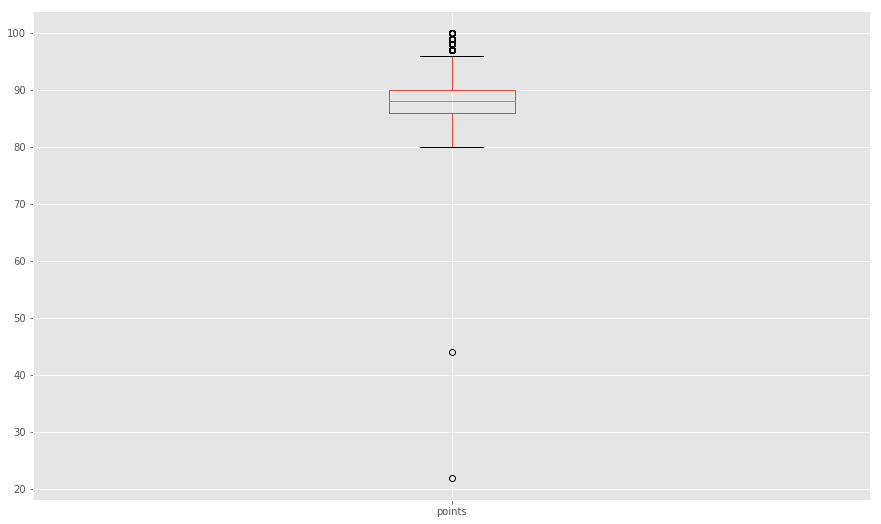

In [10]:
df2.boxplot(column='points', by=None)

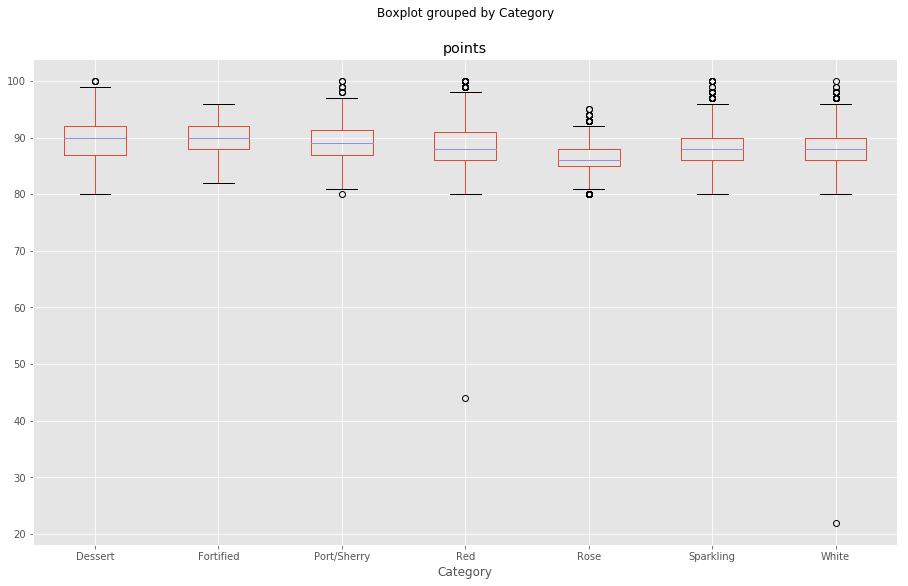

In [11]:
df2.boxplot(column='points', by='Category')

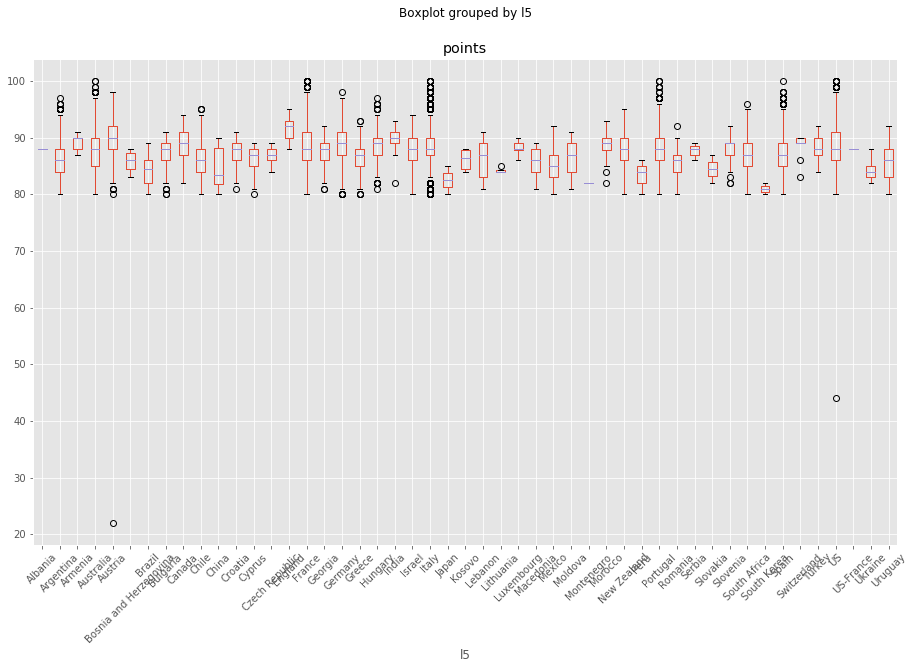

In [12]:
df2.boxplot(column='points', by='l5',rot=45)

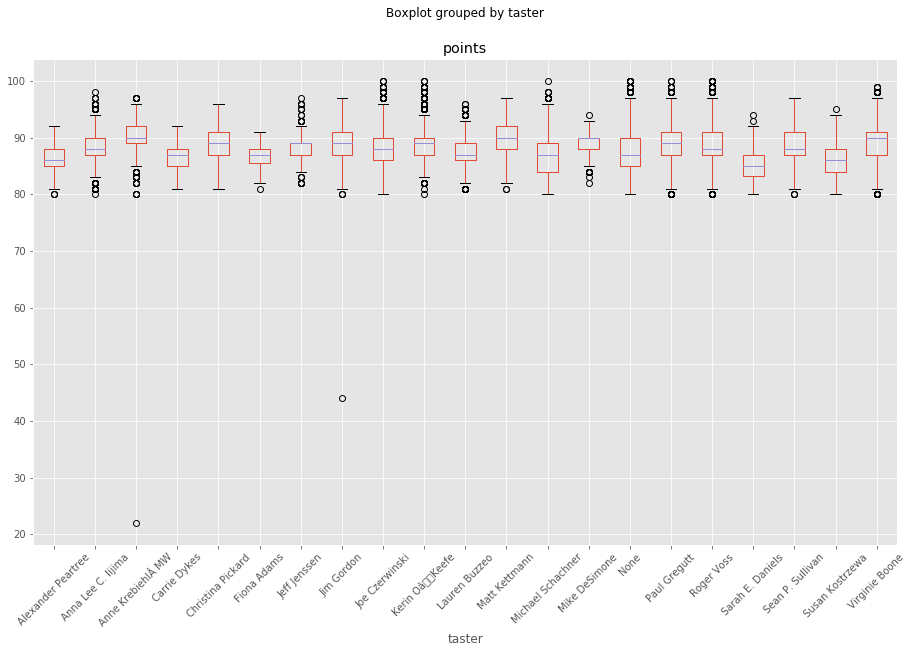

In [13]:
df2.boxplot(column='points', by='taster',rot=45)

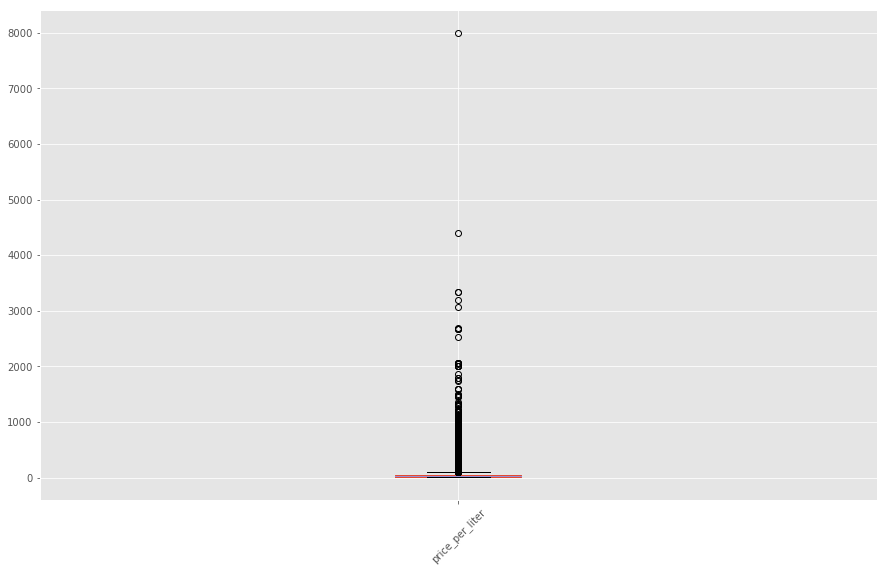

In [14]:
df2.boxplot(column='price_per_liter', by=None,rot=45)

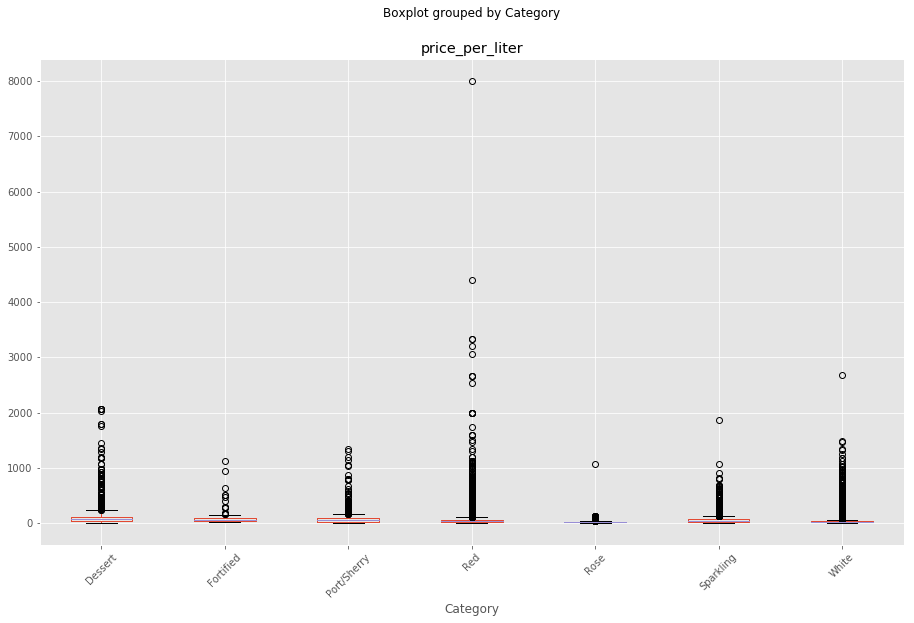

In [15]:
df2.boxplot(column='price_per_liter', by='Category',rot=45)

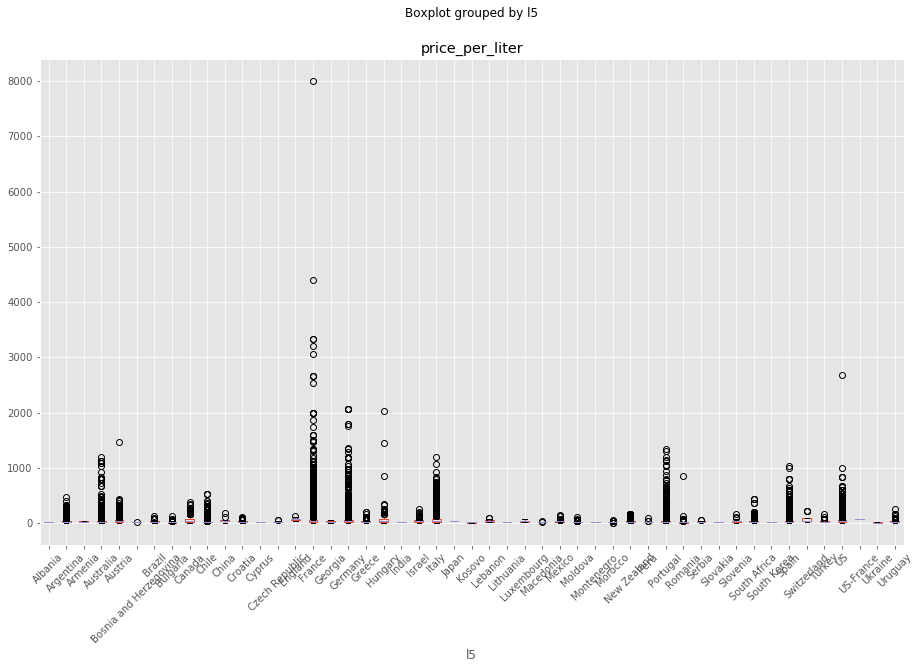

In [16]:
df2.boxplot(column='price_per_liter', by='l5',rot=45)

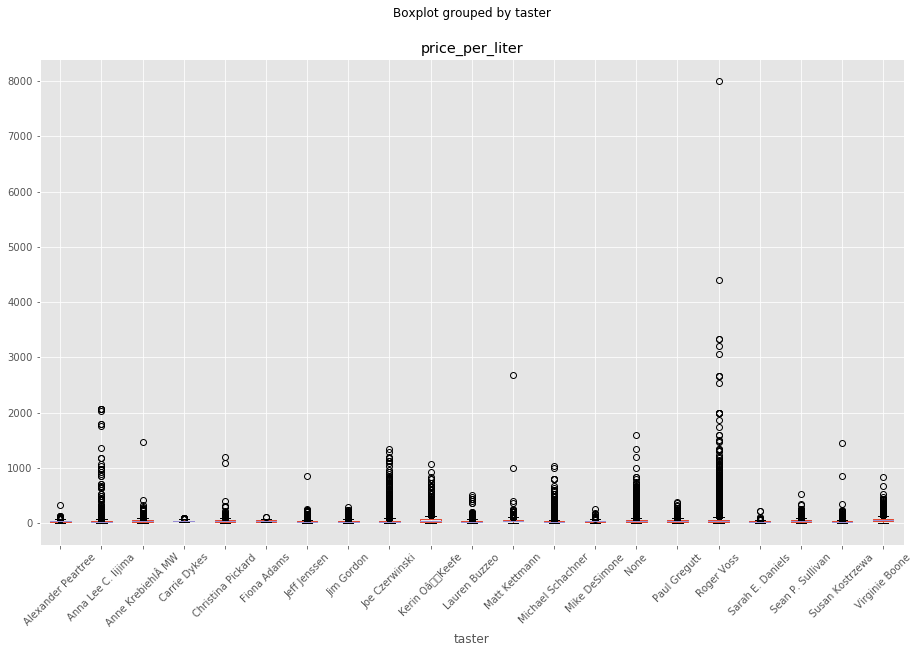

In [17]:
df2.boxplot(column='price_per_liter', by='taster',rot=45)

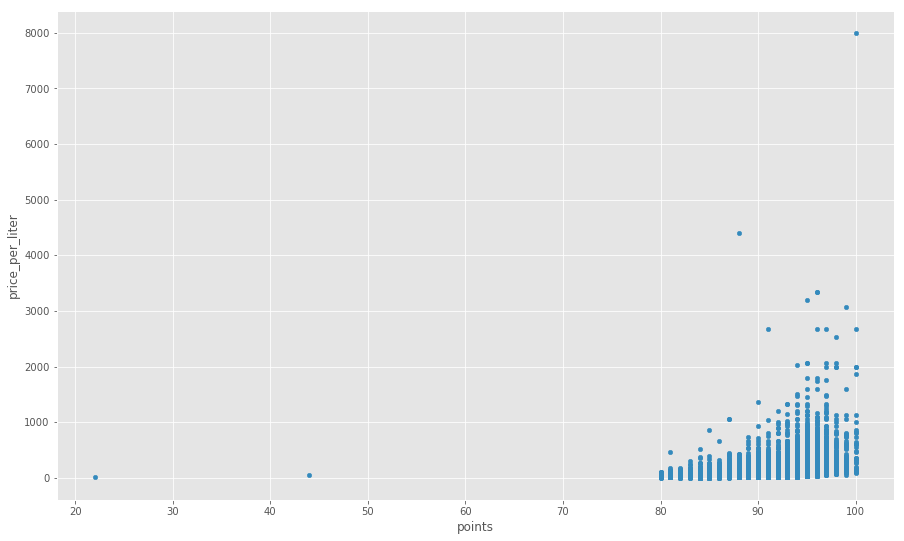

In [18]:
df2.plot.scatter(x='points', y='price_per_liter')

In [19]:
def return_model_data(train_size, pca_i, input_df, keep_vars, save_tools = False):
    lookupTable1, indexed_1 = np.unique(input_df[['taster']],   return_inverse=True)
    lookupTable2, indexed_2 = np.unique(input_df[['Category']], return_inverse=True)
    lookupTable3, indexed_3 = np.unique(input_df[['l5']],       return_inverse=True)

    train_test_split_output = train_test_split(input_df, indexed_1,indexed_2,indexed_3, random_state=1, test_size=1-train_size)

    df_train, df_test, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test = train_test_split_output

    vectorizer = TfidfVectorizer()
    #vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))
    vectorizer.fit(df_train.description.tolist())
    if save_tools:
        joblib.dump(vectorizer, 'vectorizer.pkl')

    Tfidf_df_train = vectorizer.transform(df_train.description.tolist())
    Tfidf_df_test = vectorizer.transform(df_test.description.tolist())

    input_df_train = df_train.reset_index(drop=True).copy(deep=True)
    input_df_test = df_test.reset_index(drop=True).copy(deep=True)

    my_normalizer1 = Normalizer()
    my_normalizer1.fit(Tfidf_df_train)
    if save_tools:
        joblib.dump(normalizer1, 'normalizer1.pkl')

    Tfidf_df_train = my_normalizer1.transform(Tfidf_df_train)
    Tfidf_df_test = my_normalizer1.transform(Tfidf_df_test)

    svd1 = TruncatedSVD(n_components=pca_i, n_iter=7, random_state=42)
    svd1.fit(Tfidf_df_train)
    if save_tools:
        joblib.dump(svd1, 'svd1.pkl')

    text_df_train = pd.DataFrame(svd1.transform(Tfidf_df_train))
    text_df_train = text_df_train.reset_index(drop=True)
    text_df_test = pd.DataFrame(svd1.transform(Tfidf_df_test))
    text_df_test = text_df_test.reset_index(drop=True)

    final_input_train = pd.concat([input_df_train[keep_vars],text_df_train], axis=1)
    final_input_test = pd.concat([input_df_test[keep_vars],text_df_test], axis=1)

    scaler = StandardScaler()
    scaler.fit(final_input_train)
    if save_tools:
        joblib.dump(scaler, 'scaler.pkl')

    XTrain = scaler.transform(final_input_train)
    XTest = scaler.transform(final_input_test)

    return(XTrain, XTest, 
           y1_train, y1_test, 
           y2_train, y2_test, 
           y3_train, y3_test,
           lookupTable1,lookupTable2,lookupTable3,
           vectorizer,my_normalizer1,svd1,scaler)

In [60]:
train_size=.01
pca_i=50
output_data = return_model_data(train_size=train_size, pca_i=pca_i, input_df=df2, keep_vars=['points','price_per_liter'])
XTrain, XTest, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test,lookupTable1,lookupTable2,lookupTable3,vectorizer,normalizer1,svd1,scaler = output_data

# MLPClassifier

In [21]:
mlpc = MLPClassifier(solver='lbfgs', alpha=1e-5, random_state=1)
mlpc.fit(XTrain, y1_train)  
y_pred_train = mlpc.predict(XTrain)
y_pred_test = mlpc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.69877332204


In [22]:
mlpc = MLPClassifier(solver='lbfgs', alpha=1e-5, random_state=1)
mlpc.fit(XTrain, y2_train)  
y_pred_train = mlpc.predict(XTrain)
y_pred_test = mlpc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.858154833804


In [23]:
mlpc = MLPClassifier(solver='lbfgs', alpha=1e-5, random_state=1)
mlpc.fit(XTrain, y3_train)  
y_pred_train = mlpc.predict(XTrain)
y_pred_test = mlpc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.582068076055


# BaggingClassifier

In [24]:
bgc = BaggingClassifier(random_state=41)
bgc.fit(XTrain, y1_train)  
y_pred_train = bgc.predict(XTrain)
y_pred_test = bgc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 0.993326978074 	 0.569632862842


In [25]:
bgc = BaggingClassifier(random_state=41)
bgc.fit(XTrain, y2_train)  
y_pred_train = bgc.predict(XTrain)
y_pred_test = bgc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 0.988083889418 	 0.850993998951


In [26]:
bgc = BaggingClassifier(random_state=41)
bgc.fit(XTrain, y3_train)  
y_pred_train = bgc.predict(XTrain)
y_pred_test = bgc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 0.990943755958 	 0.597799775743


# AdaBoostClassifier

In [27]:
abc = AdaBoostClassifier(random_state=41)
abc.fit(XTrain, y1_train)  
y_pred_train = abc.predict(XTrain)
y_pred_test = abc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 0.370829361296 	 0.379793741007


In [28]:
abc = AdaBoostClassifier(random_state=41)
abc.fit(XTrain, y2_train)  
y_pred_train = abc.predict(XTrain)
y_pred_test = abc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 0.780266920877 	 0.790694764602


In [29]:
abc = AdaBoostClassifier(random_state=41)
abc.fit(XTrain, y3_train)  
y_pred_train = abc.predict(XTrain)
y_pred_test = abc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 0.491420400381 	 0.500733889325


# DecisionTree

In [30]:
for max_depth in range(5,20):
    decisionTree = DecisionTreeClassifier(max_depth=max_depth)
    decisionTree.fit(XTrain, y1_train)  
    y_pred_train = decisionTree.predict(XTrain)
    y_pred_test = decisionTree.predict(XTest)
    print(max_depth,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

5 	 0.01 	 50 	 0.517159199237 	 0.493438307579
6 	 0.01 	 50 	 0.561963775024 	 0.511653199998
7 	 0.01 	 50 	 0.60962821735 	 0.512894796364
8 	 0.01 	 50 	 0.661582459485 	 0.509843741729
9 	 0.01 	 50 	 0.725929456625 	 0.486287097504
10 	 0.01 	 50 	 0.787893231649 	 0.488972410574
11 	 0.01 	 50 	 0.84795042898 	 0.484881879912
12 	 0.01 	 50 	 0.889418493804 	 0.474934671819
13 	 0.01 	 50 	 0.922783603432 	 0.479058889204
14 	 0.01 	 50 	 0.949952335558 	 0.477052122985
15 	 0.01 	 50 	 0.969018112488 	 0.474804737316
16 	 0.01 	 50 	 0.980457578646 	 0.469549608512
17 	 0.01 	 50 	 0.987130600572 	 0.470550585427
18 	 0.01 	 50 	 0.989990467112 	 0.466869107831
19 	 0.01 	 50 	 0.992373689228 	 0.469934599633


In [31]:
for max_depth in range(5,20):
    decisionTree = DecisionTreeClassifier(max_depth=max_depth)
    decisionTree.fit(XTrain, y2_train)  
    y_pred_train = decisionTree.predict(XTrain)
    y_pred_test = decisionTree.predict(XTest)
    print(max_depth,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

5 	 0.01 	 50 	 0.879408960915 	 0.835733913387
6 	 0.01 	 50 	 0.902764537655 	 0.833905205561
7 	 0.01 	 50 	 0.923736892278 	 0.828284335193
8 	 0.01 	 50 	 0.940419447092 	 0.823409385121
9 	 0.01 	 50 	 0.950428979981 	 0.815011766291
10 	 0.01 	 50 	 0.959485224023 	 0.812408263834
11 	 0.01 	 50 	 0.967588179218 	 0.812090646159
12 	 0.01 	 50 	 0.976167778837 	 0.803336910543
13 	 0.01 	 50 	 0.983317445186 	 0.798519709139
14 	 0.01 	 50 	 0.987607244995 	 0.797956659625
15 	 0.01 	 50 	 0.992373689228 	 0.797744914508
16 	 0.01 	 50 	 0.995233555767 	 0.795377219113
17 	 0.01 	 50 	 0.996663489037 	 0.796079827909
18 	 0.01 	 50 	 0.998093422307 	 0.797412859666
19 	 0.01 	 50 	 0.99857006673 	 0.793327141393


In [32]:
for max_depth in range(5,20):
    decisionTree = DecisionTreeClassifier(max_depth=max_depth)
    decisionTree.fit(XTrain, y3_train)  
    y_pred_train = decisionTree.predict(XTrain)
    y_pred_test = decisionTree.predict(XTest)
    print(max_depth,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

5 	 0.01 	 50 	 0.60819828408 	 0.56407936592
6 	 0.01 	 50 	 0.630600571973 	 0.553174492413
7 	 0.01 	 50 	 0.683984747378 	 0.539978921736
8 	 0.01 	 50 	 0.720209723546 	 0.528116382816
9 	 0.01 	 50 	 0.772163965682 	 0.522789068177
10 	 0.01 	 50 	 0.814585319352 	 0.515729293493
11 	 0.01 	 50 	 0.853193517636 	 0.506253699524
12 	 0.01 	 50 	 0.878455672069 	 0.493269873964
13 	 0.01 	 50 	 0.902764537655 	 0.484660510017
14 	 0.01 	 50 	 0.922783603432 	 0.481566143881
15 	 0.01 	 50 	 0.943755958055 	 0.476647882308
16 	 0.01 	 50 	 0.961868446139 	 0.477047310596
17 	 0.01 	 50 	 0.973784556721 	 0.467807523689
18 	 0.01 	 50 	 0.979980934223 	 0.469487047455
19 	 0.01 	 50 	 0.986653956149 	 0.472090549912


# RandomForestClassifier

In [33]:
rfc = RandomForestClassifier( random_state=41,n_jobs=-1)
rfc.fit(XTrain, y1_train)  
y_pred_train = rfc.predict(XTrain)
y_pred_test = rfc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 0.992850333651 	 0.551648965096


In [34]:
rfc = RandomForestClassifier( random_state=41,n_jobs=-1)
rfc.fit(XTrain, y2_train)  
y_pred_train = rfc.predict(XTrain)
y_pred_test = rfc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 0.988560533842 	 0.832899416257


In [35]:
rfc = RandomForestClassifier( random_state=41,n_jobs=-1)
rfc.fit(XTrain, y3_train)  
y_pred_train = rfc.predict(XTrain)
y_pred_test = rfc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 0.994280266921 	 0.580686920408


# ExtraTreesClassifier

In [36]:
etc = ExtraTreesClassifier( random_state=41,n_jobs=-1)
etc.fit(XTrain, y1_train)  
y_pred_train = etc.predict(XTrain)
y_pred_test = etc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.51779380838


In [37]:
etc = ExtraTreesClassifier( random_state=41,n_jobs=-1)
etc.fit(XTrain, y2_train)  
y_pred_train = etc.predict(XTrain)
y_pred_test = etc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.814010789376


In [38]:
etc = ExtraTreesClassifier( random_state=41,n_jobs=-1)
etc.fit(XTrain, y3_train)  
y_pred_train = etc.predict(XTrain)
y_pred_test = etc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 1.0 	 0.561268930735


# GradientBoostingClassifier

In [39]:
gbc = GradientBoostingClassifier()
gbc.fit(XTrain, y1_train)  
y_pred_train = gbc.predict(XTrain)
y_pred_test = gbc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 0.999523355577 	 0.636462509083


In [40]:
gbc = GradientBoostingClassifier()
gbc.fit(XTrain, y2_train)  
y_pred_train = gbc.predict(XTrain)
y_pred_test = gbc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 0.99714013346 	 0.870224305452


In [41]:
gbc = GradientBoostingClassifier()
gbc.fit(XTrain, y3_train)  
y_pred_train = gbc.predict(XTrain)
y_pred_test = gbc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 0.995710200191 	 0.624893525893


# C-Support Vector Classification

In [61]:
svc = SVC(kernel='rbf',C=3)
svc.fit(XTrain, y1_train)  
y_pred_train = svc.predict(XTrain)
y_pred_test = svc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

0.01 	 50 	 0.989037178265 	 0.729202057778


In [62]:
svc = SVC(kernel='rbf',C=3)
svc.fit(XTrain, y2_train)  
y_pred_train = svc.predict(XTrain)
y_pred_test = svc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

0.01 	 50 	 0.991420400381 	 0.886119626366


In [63]:
svc = SVC(kernel='rbf',C=3)
svc.fit(XTrain, y3_train)  
y_pred_train = svc.predict(XTrain)
y_pred_test = svc.predict(XTest)
print(train_size,"\t",pca_i, "\t",
      metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
      metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

0.01 	 50 	 0.981410867493 	 0.660861321386


# KNeighbors

In [43]:
for n_neighbors in range(2,8):
    knc = KNeighborsClassifier(n_neighbors=n_neighbors)
    gbc.fit(XTrain, y1_train)  
    y_pred_train = gbc.predict(XTrain)
    y_pred_test = gbc.predict(XTest)
    print(n_neighbors,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y1_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y1_test, y_pred = y_pred_test))

2 	 0.01 	 50 	 0.999523355577 	 0.636539507308
3 	 0.01 	 50 	 0.999523355577 	 0.636515445363
4 	 0.01 	 50 	 0.999523355577 	 0.63652988253
5 	 0.01 	 50 	 0.999523355577 	 0.636606880754
6 	 0.01 	 50 	 0.999523355577 	 0.636525070141
7 	 0.01 	 50 	 0.999523355577 	 0.636597255976


In [44]:
for n_neighbors in range(2,8):
    knc = KNeighborsClassifier(n_neighbors=n_neighbors)
    gbc.fit(XTrain, y2_train)  
    y_pred_train = gbc.predict(XTrain)
    y_pred_test = gbc.predict(XTest)
    print(n_neighbors,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y2_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y2_test, y_pred = y_pred_test))

2 	 0.01 	 50 	 0.99714013346 	 0.870354239955
3 	 0.01 	 50 	 0.99714013346 	 0.870262804564
4 	 0.01 	 50 	 0.99714013346 	 0.870262804564
5 	 0.01 	 50 	 0.99714013346 	 0.870306116065
6 	 0.01 	 50 	 0.99714013346 	 0.870272429342
7 	 0.01 	 50 	 0.99714013346 	 0.870397551456


In [45]:
for n_neighbors in range(2,8):
    knc = KNeighborsClassifier(n_neighbors=n_neighbors)
    gbc.fit(XTrain, y3_train)  
    y_pred_train = gbc.predict(XTrain)
    y_pred_test = gbc.predict(XTest)
    print(n_neighbors,"\t",train_size,"\t",pca_i, "\t",
          metrics.accuracy_score(y_true = y3_train, y_pred = y_pred_train),"\t",
          metrics.accuracy_score(y_true = y3_test, y_pred = y_pred_test))

2 	 0.01 	 50 	 0.996663489037 	 0.625759755916
3 	 0.01 	 50 	 0.995710200191 	 0.624984961284
4 	 0.01 	 50 	 0.99714013346 	 0.624195729486
5 	 0.01 	 50 	 0.996663489037 	 0.625759755916
6 	 0.01 	 50 	 0.996663489037 	 0.62598112581
7 	 0.01 	 50 	 0.996663489037 	 0.62588487803


# Cross Validation & VotingClassifier

In [56]:
train_size=.05
pca_i=50
output_data = return_model_data(train_size=train_size, pca_i=pca_i, input_df=df2, keep_vars=['points','price_per_liter'])
XTrain, XTest, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test,lookupTable1,lookupTable2,lookupTable3,vectorizer,normalizer1,svd1,scaler = output_data

In [55]:
mlpc = MLPClassifier(solver='lbfgs', alpha=1e-5, random_state=41)
bgc = BaggingClassifier(random_state=41)
abc = AdaBoostClassifier(random_state=41)
dtc = DecisionTreeClassifier(max_depth=13,random_state=41)
rfc = RandomForestClassifier( random_state=41)
etc = ExtraTreesClassifier( random_state=41)
gbc = GradientBoostingClassifier(random_state=41)
svc = SVC(kernel='rbf',C=3)
knc = KNeighborsClassifier(n_neighbors=5)

eclf = VotingClassifier(estimators=[('mlpc', mlpc),
                                    ('bgc', bgc),
                                    ('abc', abc),
                                    ('dtc', dtc),
                                    ('rfc', rfc),
                                    ('etc', etc),
                                    ('gbc', gbc),
                                    ('svc', svc),
                                    ('knc', knc)], voting='hard',n_jobs=-1)

list_of_models = [mlpc,bgc,abc,dtc,rfc,etc,gbc,svc,knc,eclf ]
list_of_models_names = ['MLP', 'Bagging', 'AdaBoostr', 'DecisionTree',
                        'RandomForest', 'ExtraTrees', 'GradientBoosting', 'C-Support Vector Classification'
                        'KNeighbors','VotingEnsemble']
for clf, label in zip(list_of_models, list_of_models_names):
    scores = cross_val_score(clf, XTrain, y1_train, cv=3, scoring='accuracy')
    print("Accuracy: %0.2f (+/- %0.2f) [%s] %s" % (scores.mean(), scores.std(), label, "y1"))
    scores = cross_val_score(clf, XTrain, y2_train, cv=3, scoring='accuracy')
    print("Accuracy: %0.2f (+/- %0.2f) [%s] %s" % (scores.mean(), scores.std(), label, "y2"))
    scores = cross_val_score(clf, XTrain, y3_train, cv=3, scoring='accuracy')
    print("Accuracy: %0.2f (+/- %0.2f) [%s] %s" % (scores.mean(), scores.std(), label, "y3"))

C:\anaconda\lib\site-packages\sklearn\model_selection\_split.py:597: Warning: The least populated class in y has only 1 members, which is too few. The minimum number of members in any class cannot be less than n_splits=3.
  % (min_groups, self.n_splits)), Warning)


Accuracy: 0.71 (+/- 0.01) [MLP] y1
Accuracy: 0.86 (+/- 0.01) [MLP] y2


C:\anaconda\lib\site-packages\sklearn\model_selection\_split.py:597: Warning: The least populated class in y has only 1 members, which is too few. The minimum number of members in any class cannot be less than n_splits=3.
  % (min_groups, self.n_splits)), Warning)


Accuracy: 0.59 (+/- 0.01) [MLP] y3


C:\anaconda\lib\site-packages\sklearn\model_selection\_split.py:597: Warning: The least populated class in y has only 1 members, which is too few. The minimum number of members in any class cannot be less than n_splits=3.
  % (min_groups, self.n_splits)), Warning)


KeyboardInterrupt: 

# Custom Neural Network

In [87]:
class neuralNetwork:
    def __init__(self, input_nodes, hidden_nodes, output_nodes, learning_rate, lookupTable1, lookupTable2,
                 lookupTable3):
        self.input_nodes = input_nodes
        self.hidden_nodes = hidden_nodes
        self.output_nodes = output_nodes
        self.weights_input_to_hidden = np.random.normal(0.0, pow(self.input_nodes, -0.5),
                                                        (self.hidden_nodes, self.input_nodes))
        self.weights_hidden_to_output = np.random.normal(0.0, pow(self.hidden_nodes, -0.5),
                                                         (self.output_nodes, self.hidden_nodes))
        self.learning_rate = learning_rate
        self.activation_function = lambda x: sc.special.expit(x)
        self.inverse_activation_function = lambda x: sc.special.logit(x)
        self.lookupTable1 = lookupTable1
        self.lookupTable2 = lookupTable2
        self.lookupTable3 = lookupTable3
        self.y1_n = len(lookupTable1)
        self.y2_n = len(lookupTable2)
        self.y3_n = len(lookupTable3)
        self.e = 0
        pass
    
    def get_e(self):
        return self.e
    
    def get_lookup_Tables(self):
        return (self.lookupTable1, self.lookupTable2, self.lookupTable3)
    
    def train(self, inputs_list, targets_list):
        inputs = np.array(inputs_list, ndmin=2).T
        targets = np.array(targets_list, ndmin=2).T
        hidden_inputs = np.dot(self.weights_input_to_hidden, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)
        final_inputs = np.dot(self.weights_hidden_to_output, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)
        output_errors = targets - final_outputs
        hidden_errors = np.dot(self.weights_hidden_to_output.T, output_errors)
        self.weights_hidden_to_output += self.learning_rate * np.dot(
            (output_errors * final_outputs * (1.0 - final_outputs)), np.transpose(hidden_outputs))
        self.weights_input_to_hidden += self.learning_rate * np.dot(
            (hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), np.transpose(inputs))
        self.e += 1
        pass

    def train_df(self, XTrain, y1_train, y2_train, y3_train):
        for x, y1, y2, y3 in zip(XTrain, y1_train, y2_train, y3_train):
            inputs = np.asfarray(x)
            targets = np.zeros(self.output_nodes) + 0.01
            targets[y1] = .99
            targets[self.y1_n + y2] = .99
            targets[self.y1_n + self.y2_n + y3] = .99
            self.train(inputs, targets)
            pass
        pass

    def query(self, inputs_list):
        inputs = np.array(inputs_list, ndmin=2).T
        hidden_inputs = np.dot(self.weights_input_to_hidden, inputs)
        hidden_outputs = self.activation_function(hidden_inputs)
        final_inputs = np.dot(self.weights_hidden_to_output, hidden_outputs)
        final_outputs = self.activation_function(final_inputs)
        return final_outputs

    def back_query(self, targets_list):
        final_outputs = np.array(targets_list, ndmin=2).T
        final_inputs = self.inverse_activation_function(final_outputs)
        hidden_outputs = np.dot(self.weights_hidden_to_output.T, final_inputs)
        hidden_outputs -= np.min(hidden_outputs)
        hidden_outputs /= np.max(hidden_outputs)
        hidden_outputs *= 0.98
        hidden_outputs += 0.01
        hidden_inputs = self.inverse_activation_function(hidden_outputs)
        inputs = np.dot(self.weights_input_to_hidden.T, hidden_inputs)
        return inputs

    def get_target(self, country, category, taster):
        targets = np.zeros(self.output_nodes) + 0.01
        targets[self.lookupTable1.tolist().index(taster)] = .99
        targets[self.y1_n + self.lookupTable2.tolist().index(category)] = .99
        targets[self.y1_n + self.y2_n + self.lookupTable3.tolist().index(country)] = .99
        return targets
    
    def create_word_cloud(self, cuttoff, country, category, taster, vectorizer, scaler, svd, map_mask_path):
        my_input = self.back_query(self.get_target(country, category, taster))
        my_input2 = scaler.inverse_transform([x[0] for x in my_input])
        my_input3 = svd.inverse_transform(my_input2[2:].reshape(1, -1))
        my_features = vectorizer.get_feature_names()
        my_dic ={}
        i = 0
        for x in my_input3[0]:
            if x >cuttoff:
                my_dic[my_features[i]]= math.floor(x*1000)
            i += 1

        map_mask = np.array(Image.open(map_mask_path))
        wc = WordCloud(background_color="white", max_words=2000, mask=map_mask)
        wc.generate_from_frequencies(my_dic)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.show()

    def get_accuracy(self, XTrain, y1_train, y2_train, y3_train):
        count_right1 = 0
        count_right2 = 0
        count_right3 = 0
        count_total = 0
        for x, y1, y2, y3 in zip(XTrain, y1_train, y2_train, y3_train):
            inputs = np.asfarray(x)
            predicted_value = self.query(inputs)
            y_1_prediction = np.argmax([predicted_value[i][0] for i in range(0, self.y1_n)])
            y_2_prediction = np.argmax([predicted_value[i][0] for i in range(self.y1_n, self.y1_n + self.y2_n)])
            y_3_prediction = np.argmax(
                [predicted_value[i][0] for i in range(self.y1_n + self.y2_n, self.y1_n + self.y2_n + self.y3_n)])
            count_total += 1
            if y1 == y_1_prediction:
                count_right1 += 1
            if y2 == y_2_prediction:
                count_right2 += 1
            if y3 == y_3_prediction:
                count_right3 += 1
        print(self.hidden_nodes, self.e, count_total, count_right1 / count_total, count_right2 / count_total,
              count_right3 / count_total, count_total, sep='\t')
        return (self.hidden_nodes, self.e, count_total, count_right1 / count_total, count_right2 / count_total,
                count_right3 / count_total, count_total)

In [82]:
train_size=.5
pca_i=1500
output_data = return_model_data(train_size=train_size, pca_i=pca_i, input_df=df2, keep_vars=['points','price_per_liter'])
XTrain, XTest, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test, lookupTable1, lookupTable2, lookupTable3, vectorizer, normalizer1, svd1, scaler = output_data


In [88]:
y1_n= len(lookupTable1)
y2_n= len(lookupTable2)
y3_n= len(lookupTable3)

# number of input, hidden and output nodes
input_nodes = XTrain.shape[1]
hidden_nodes = 100
output_nodes = y1_n + y2_n + y3_n

# learning rate
learning_rate = 0.001

n = neuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate, lookupTable1, lookupTable2, lookupTable3)

In [89]:
epochs = 1
for e in range(epochs):
    XTrain, y1_train, y2_train, y3_train = shuffle(XTrain, y1_train,y2_train,y3_train, random_state=41)
    n.train_df(XTrain,y1_train, y2_train, y3_train)
    n.get_accuracy(XTrain, y1_train, y2_train, y3_train)
    n.get_accuracy(XTest, y1_test, y2_test, y3_test)
    pass

100	104947	104947	0.8336112513935605	0.9178728310480528	0.733389234566019	104947
100	104947	104948	0.823722224339673	0.9169969889850211	0.7275126729427908	104948


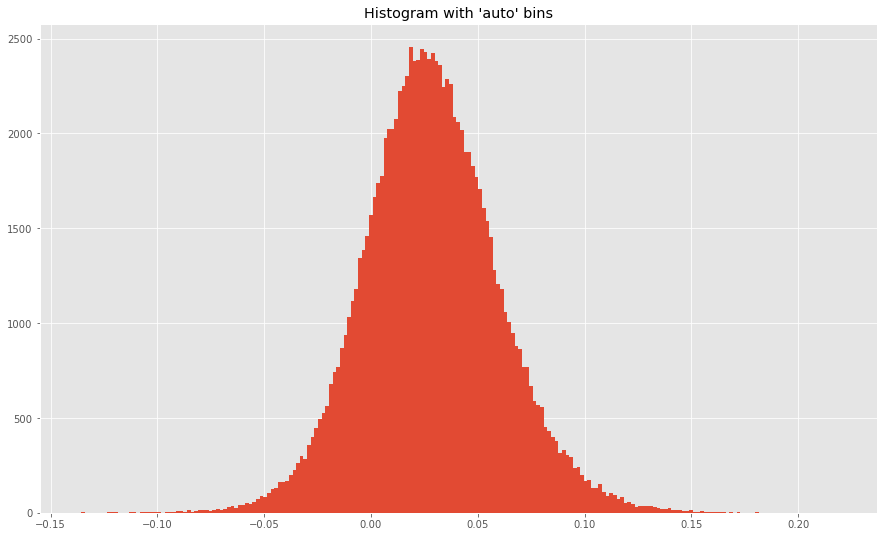

In [92]:
cor_array = []
for x,y1,y2,y3 in zip(XTrain,y1_train, y2_train, y3_train):
    inputs = np.asfarray(x)
    targets = np.zeros(output_nodes) + 0.01
    targets[y1] = .99
    targets[y1_n+y2] = .99
    targets[y1_n+y2_n+y3] = .99
    cor_array.append(sc.stats.spearmanr(np.asfarray([x[0] for x in n.back_query(targets)]),inputs).correlation)
    pass
import matplotlib.pyplot as plt
plt.hist(cor_array, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")
plt.show()

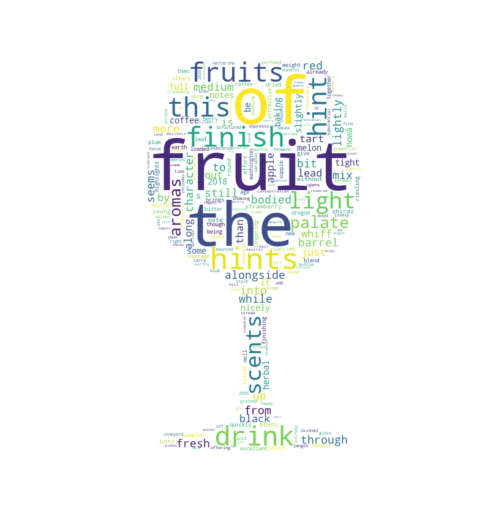

In [90]:
n.create_word_cloud(cuttoff=0,country='Israel', category='Red', taster='Paul Gregutt',
                  vectorizer=vectorizer,scaler= scaler, svd=svd1 ,
                    map_mask_path="wine2_removed.png")